In [5]:
#@title Identification of Key Clinical Predictors of Alzheimer’s Disease Using Supervised Machine Learning Models

In [6]:
#@title Information of Dataset:
# This dataset contains extensive health information for 2149 patients that includes demographic details, lifestyle factors, medical history, clinical measurements
# Cognitive and functional assessments, and diagnosis of Alzheimer's disease.
# 1) Gender - 0 = Male and 1 = Female
# 2) Ethnicity - 0 = Caucasian, 1 = African American, 2 = Asian and 3 = Other
# 3) Education Level - 0 = None, 1 = High School, 2 = Bachelor's, 3 = Higher
# 4) Smoking - 0 = No and 1 = Yes
# 5) Alcohol Consumption - Weekly Consumption ranging from 0 to 20
# 6) Physical Activity - Weekly in hours ranging from 0 to 10
# 7) Diet Quality - Score ranging from 0 to 10
# 8) Sleep Quality - Score ranging from 4 to 10
# 9) FamilyHistoryAlzheimers: 0 = No and 1 = Yes.
# 10) CardiovascularDisease: Presence of cardiovascular disease, where 0 indicates No and 1 indicates Yes.
# 11) Diabetes: Presence of diabetes, where 0 indicates No and 1 indicates Yes.
# 12) Depression: Presence of depression, where 0 indicates No and 1 indicates Yes.
# 13)HeadInjury: History of head injury, where 0 indicates No and 1 indicates Yes.
# 14)Hypertension: Presence of hypertension, where 0 indicates No and 1 indicates Yes.
# 15)Clinical Measurements
# 16)SystolicBP: Systolic blood pressure, ranging from 90 to 180 mmHg.
# 17)DiastolicBP: Diastolic blood pressure, ranging from 60 to 120 mmHg.
# 18)CholesterolTotal: Total cholesterol levels, ranging from 150 to 300 mg/dL.
# 19)CholesterolLDL: Low-density lipoprotein cholesterol levels, ranging from 50 to 200 mg/dL.
# 20)CholesterolHDL: High-density lipoprotein cholesterol levels, ranging from 20 to 100 mg/dL.
# 21)CholesterolTriglycerides: Triglycerides levels, ranging from 50 to 400 mg/dL.
# 22)Cognitive and Functional Assessments
# 23)MMSE: Mini-Mental State Examination score, ranging from 0 to 30. Lower scores indicate cognitive impairment.
# 24)FunctionalAssessment: Functional assessment score, ranging from 0 to 10. Lower scores indicate greater impairment.
# 25)MemoryComplaints: Presence of memory complaints, where 0 indicates No and 1 indicates Yes.
# 26)BehavioralProblems: Presence of behavioral problems, where 0 indicates No and 1 indicates Yes.
# 27)ADL: Activities of Daily Living score, ranging from 0 to 10. Lower scores indicate greater impairment.
# 28)Symptoms
 #1. Confusion: Presence of confusion, where 0 indicates No and 1 indicates Yes.
 #2. Disorientation: Presence of disorientation, where 0 indicates No and 1 indicates Yes.
 #3. PersonalityChanges: Presence of personality changes, where 0 indicates No and 1 indicates Yes.
 #4. DifficultyCompletingTasks: Presence of difficulty completing tasks, where 0 indicates No and 1 indicates Yes.
 #5. Forgetfulness: Presence of forgetfulness, where 0 indicates No and 1 indicates Yes.
# 29)Diagnosis Information
# Diagnosis: Diagnosis status for Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.

In [1]:
# SECTION 1: Load and Inspect Dataset

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Project_AI_ML.csv")

# Display top rows
print("HEAD OF DATASET:")
display(df.head())

# Dataset shape
print("\n SHAPE OF DATASET:", df.shape)

# Info about data types and missing values
print("\n DATASET INFO:")
print(df.info())

# Check for missing values directly
print("\n MISSING VALUES PER COLUMN:")
print(df.isnull().sum())


HEAD OF DATASET:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,6.045039,0,0,0.014691,0,0,1,1,0,0



 SHAPE OF DATASET: (2149, 34)

 DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  D

In [5]:
# -----------------------------------------
# SECTION 2: Preprocessing + Train/Test Split
# -----------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
#    - Drop 'Diagnosis' because it's the label we want to predict
#    - Drop 'PatientID' because it's just an identifier, not a clinical feature

X = df.drop(['Diagnosis', 'PatientID'], axis=1)
y = df['Diagnosis']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

# 2. Check class balance (how many 0 vs 1 in Diagnosis)
print("\nDiagnosis class distribution:")
print(y.value_counts())
print("\nDiagnosis class distribution (percentage):")
print(y.value_counts(normalize=True) * 100)

# 3. Train-test split
#    - test_size = 0.2 (80% train, 20% test)
#    - stratify = y (Keeps same class proportion in train & test)
#    - random_state = 42 (Reproducibility)

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, stratify=y, random_state=42)

print("\nTrain set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# 4. Scaling (for models that need it: Logistic Regression, SVM, Neural Network, Naive Bayes)
#    - We will create scaled versions: X_train_scaled, X_test_scaled
#    - Tree-based models (Decision Tree, Random Forest, XGBoost) will use the ORIGINAL X_train, X_test

scaler = StandardScaler()

# Fit on training data only, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Scaling done. Shapes:")
print("   X_train_scaled:", X_train_scaled.shape)
print("   X_test_scaled :", X_test_scaled.shape)


Features shape (X): (2149, 32)
Target shape (y): (2149,)

Diagnosis class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Diagnosis class distribution (percentage):
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64

Train set shape: (1719, 32) (1719,)
Test set shape: (430, 32) (430,)

✅ Scaling done. Shapes:
   X_train_scaled: (1719, 32)
   X_test_scaled : (430, 32)


Logistic Regression Performance Metrics
-----------------------------------------
Accuracy      : 0.8162790697674419
Precision     : 0.7417218543046358
Recall        : 0.7368421052631579
F1-score      : 0.7392739273927392
ROC-AUC       : 0.8853653918970088

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430



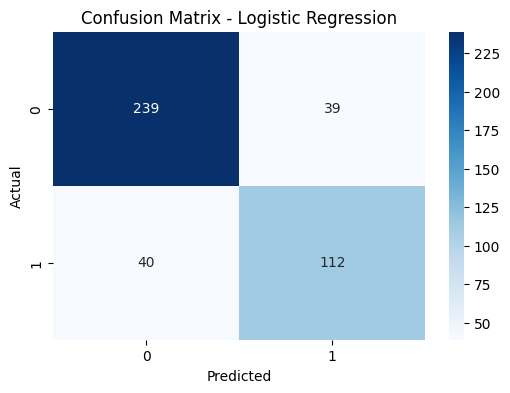

In [6]:
# -----------------------------------------
# SECTION 3: Logistic Regression
# -----------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Create Logistic Regression model
log_reg = LogisticRegression(max_iter=500, random_state=42)

# Fit model on scaled data
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]   # probability for ROC-AUC

# -----------------------------------------
# METRICS
# -----------------------------------------

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance Metrics")
print("-----------------------------------------")
print("Accuracy      :", accuracy_lr)
print("Precision     :", precision_lr)
print("Recall        :", recall_lr)
print("F1-score      :", f1_lr)
print("ROC-AUC       :", roc_auc_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# -----------------------------------------
# CONFUSION MATRIX
# -----------------------------------------
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Gaussian Naive Bayes Performance Metrics
-----------------------------------------
Accuracy      : 0.772093023255814
Precision     : 0.6708860759493671
Recall        : 0.6973684210526315
F1-score      : 0.6838709677419355
ROC-AUC       : 0.8503881105641801

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       278
           1       0.67      0.70      0.68       152

    accuracy                           0.77       430
   macro avg       0.75      0.76      0.75       430
weighted avg       0.77      0.77      0.77       430



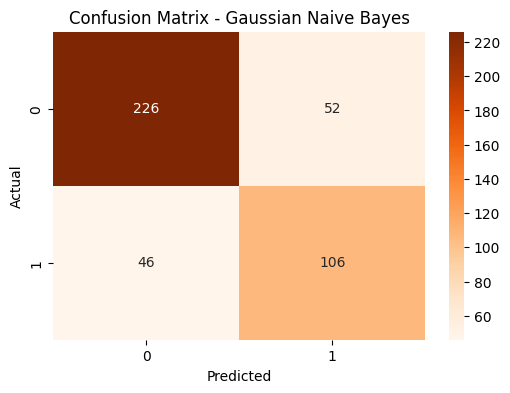

In [8]:
# -----------------------------------------
# SECTION 4: Gaussian Naive Bayes
# -----------------------------------------

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Create the model
gnb = GaussianNB()

# Fit on scaled data
gnb.fit(X_train_scaled, y_train)

# Predictions
y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]  # Needed for AUC

# -----------------------------------------
# METRICS
# -----------------------------------------

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)
roc_auc_gnb = roc_auc_score(y_test, y_prob_gnb)

print("Gaussian Naive Bayes Performance Metrics")
print("-----------------------------------------")
print("Accuracy      :", accuracy_gnb)
print("Precision     :", precision_gnb)
print("Recall        :", recall_gnb)
print("F1-score      :", f1_gnb)
print("ROC-AUC       :", roc_auc_gnb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb))

# -----------------------------------------
# CONFUSION MATRIX
# -----------------------------------------
cm = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Performance Metrics
-----------------------------------------
Accuracy      : 0.9
Precision     : 0.8471337579617835
Recall        : 0.875
F1-score      : 0.86084142394822
ROC-AUC       : 0.8943345323741007

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       278
           1       0.85      0.88      0.86       152

    accuracy                           0.90       430
   macro avg       0.89      0.89      0.89       430
weighted avg       0.90      0.90      0.90       430



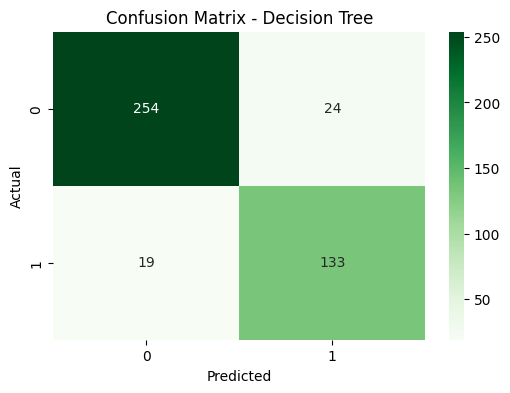

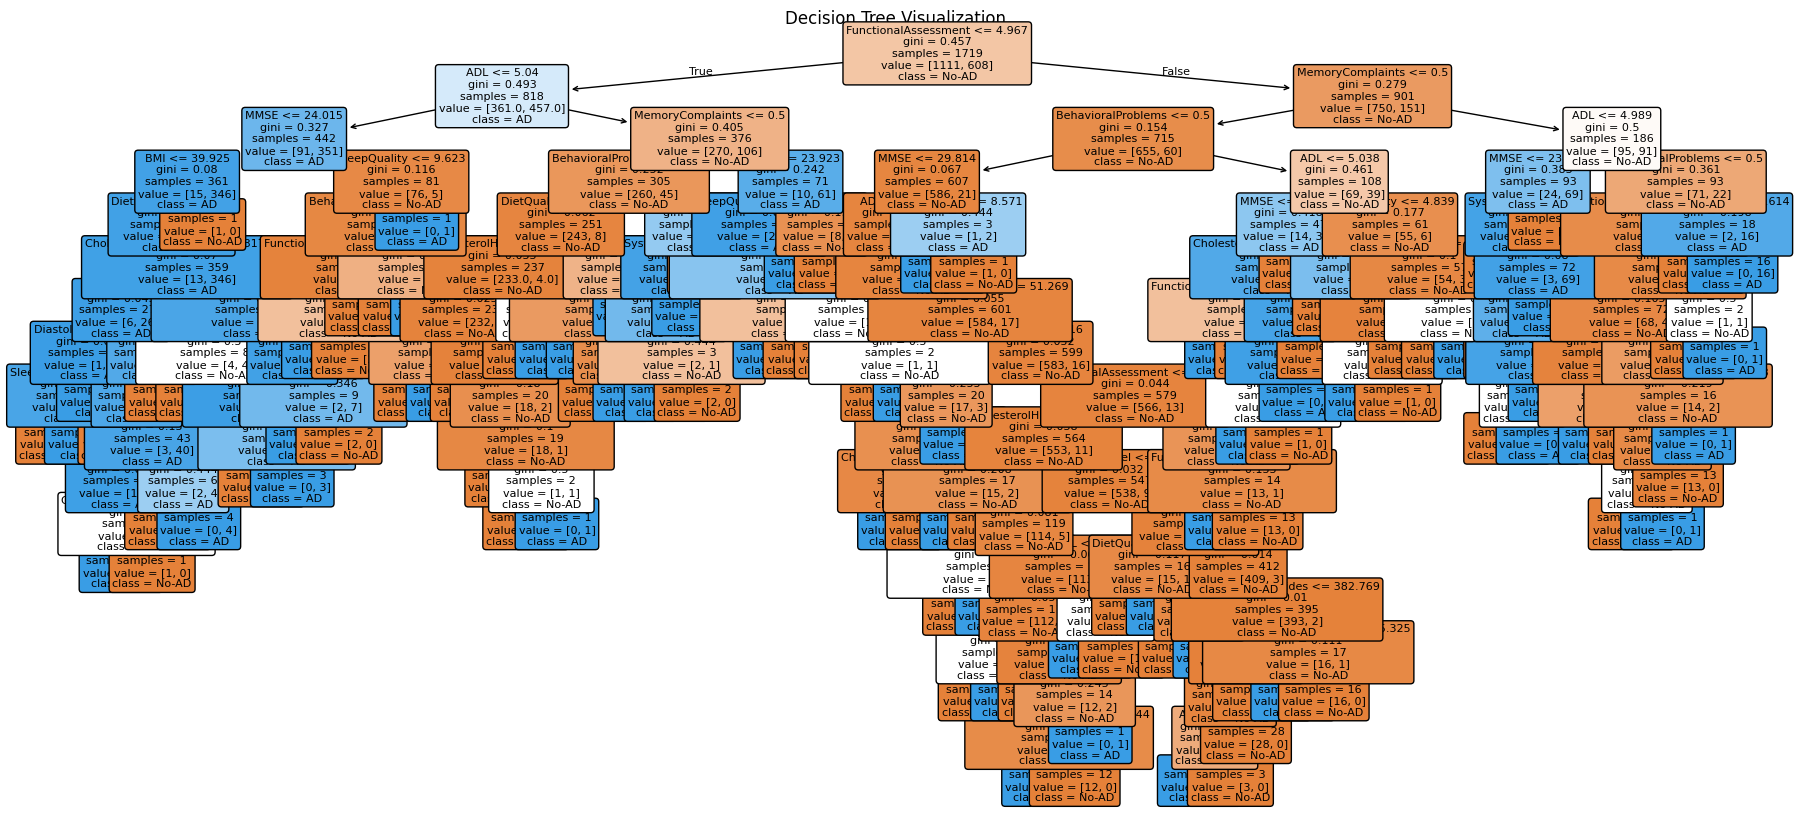

In [9]:
# -----------------------------------------
# SECTION 5: Decision Tree Classifier
# -----------------------------------------

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Create Decision Tree model
# max_depth is optional — if not set, the tree grows fully (can overfit)
dt = DecisionTreeClassifier(random_state=42)

# Fit on NON-SCALED data
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]   # probability for ROC-AUC

# -----------------------------------------
# METRICS
# -----------------------------------------

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance Metrics")
print("-----------------------------------------")
print("Accuracy      :", accuracy_dt)
print("Precision     :", precision_dt)
print("Recall        :", recall_dt)
print("F1-score      :", f1_dt)
print("ROC-AUC       :", roc_auc_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# -----------------------------------------
# CONFUSION MATRIX
# -----------------------------------------

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -----------------------------------------
# VISUALIZING THE DECISION TREE
# -----------------------------------------

plt.figure(figsize=(22,10))
plot_tree(dt, feature_names=X.columns, class_names=['No-AD','AD'],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Visualization")
plt.show()


Random Forest Performance Metrics
-----------------------------------------
Accuracy      : 0.9488372093023256
Precision     : 0.9452054794520548
Recall        : 0.9078947368421053
F1-score      : 0.9261744966442953
ROC-AUC       : 0.9399848542218856

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.95      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



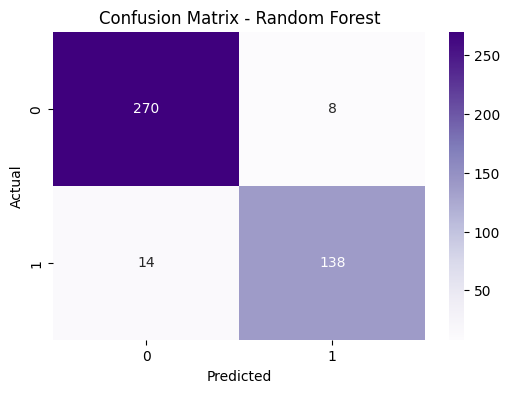

/tmp/ipython-input-2722289964.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importances.head(15), palette="viridis")


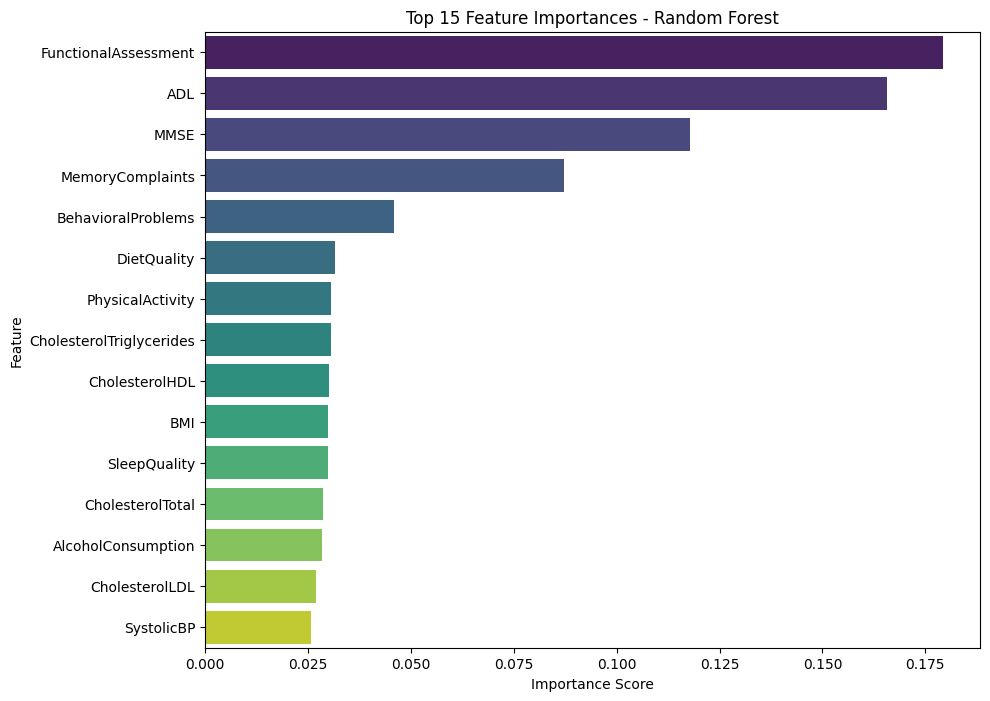


Full Feature Importance Ranking:


,Feature,Importance
23,FunctionalAssessment,0.179314
26,ADL,0.165598
22,MMSE,0.117780
24,MemoryComplaints,0.087130
25,BehavioralProblems,0.045914
8,DietQuality,0.031496
7,PhysicalActivity,0.030577
21,CholesterolTriglycerides,0.030485
20,CholesterolHDL,0.030072
4,BMI,0.029929


In [10]:
# -----------------------------------------
# SECTION 6: Random Forest Classifier
# -----------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,        # number of trees
    random_state=42,
    n_jobs=-1,              # use all CPU cores
)

# Fit on NON-SCALED data
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# -----------------------------------------
# METRICS
# -----------------------------------------

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance Metrics")
print("-----------------------------------------")
print("Accuracy      :", accuracy_rf)
print("Precision     :", precision_rf)
print("Recall        :", recall_rf)
print("F1-score      :", f1_rf)
print("ROC-AUC       :", roc_auc_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# -----------------------------------------
# CONFUSION MATRIX
# -----------------------------------------

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -----------------------------------------
# FEATURE IMPORTANCE PLOT
# -----------------------------------------

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=importances.head(15), palette="viridis")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Display full importance table
print("\nFull Feature Importance Ranking:")
display(importances)


In [11]:
!pip install xgboost

XGBoost Performance Metrics
-----------------------------------------
Accuracy      : 0.9488372093023256
Precision     : 0.9391891891891891
Recall        : 0.9144736842105263
F1-score      : 0.9266666666666666
ROC-AUC       : 0.9434399848542219

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.94      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



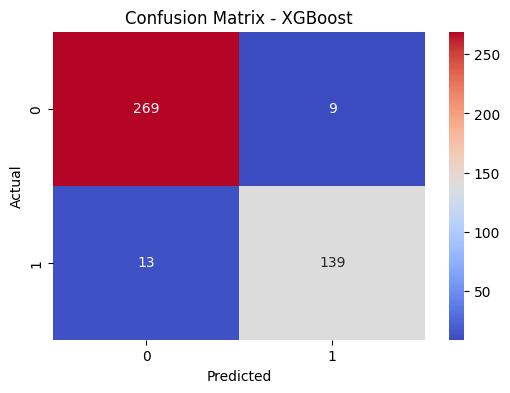

/tmp/ipython-input-738156202.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_importance.head(15), palette='magma')


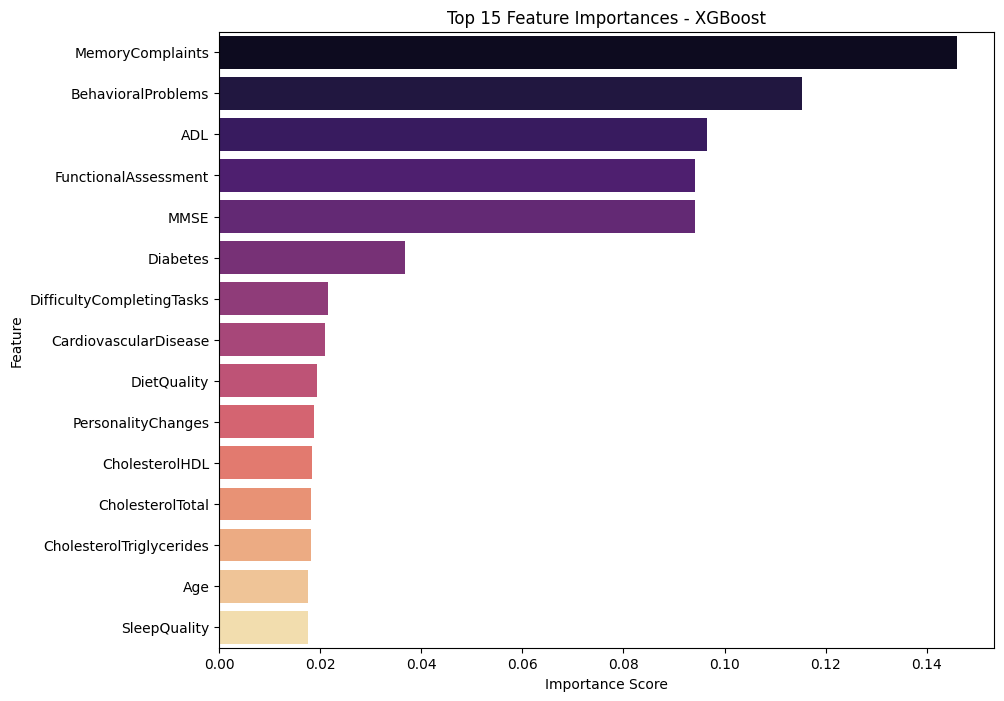


Full XGBoost Feature Importance Ranking:


,Feature,Importance
24,MemoryComplaints,0.146003
25,BehavioralProblems,0.115257
26,ADL,0.096480
23,FunctionalAssessment,0.094222
22,MMSE,0.094180
12,Diabetes,0.036691
30,DifficultyCompletingTasks,0.021604
11,CardiovascularDisease,0.020866
8,DietQuality,0.019292
29,PersonalityChanges,0.018848


In [13]:
# -----------------------------------------
# SECTION 7: XGBoost Classifier
# -----------------------------------------

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Create XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Fit on NON-SCALED data (XGBoost handles raw features well)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# -----------------------------------------
# METRICS
# -----------------------------------------

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance Metrics")
print("-----------------------------------------")
print("Accuracy      :", accuracy_xgb)
print("Precision     :", precision_xgb)
print("Recall        :", recall_xgb)
print("F1-score      :", f1_xgb)
print("ROC-AUC       :", roc_auc_xgb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# -----------------------------------------
# CONFUSION MATRIX
# -----------------------------------------

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------------------
# FEATURE IMPORTANCE
# -----------------------------------------

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance.head(15), palette='magma')
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

print("\nFull XGBoost Feature Importance Ranking:")
display(xgb_importance)

SVM Performance Metrics
-----------------------------------------
Accuracy      : 0.8348837209302326
Precision     : 0.7913669064748201
Recall        : 0.7236842105263158
F1-score      : 0.7560137457044673
ROC-AUC       : 0.8962869178341537

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       278
           1       0.79      0.72      0.76       152

    accuracy                           0.83       430
   macro avg       0.82      0.81      0.82       430
weighted avg       0.83      0.83      0.83       430



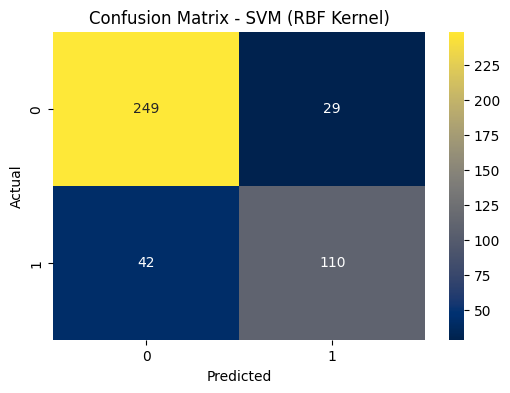

In [15]:
# -----------------------------------------
# SECTION 8: Support Vector Machine (SVM)
# -----------------------------------------

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Create SVM model (probability=True allows ROC-AUC)
svm = SVC(
    kernel='rbf',           # RBF kernel = nonlinear powerful kernel
    probability=True,       # Needed to compute probabilities
    random_state=42
)

# Train on SCALED data
svm.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

# -----------------------------------------
# METRICS
# -----------------------------------------

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("SVM Performance Metrics")
print("-----------------------------------------")
print("Accuracy      :", accuracy_svm)
print("Precision     :", precision_svm)
print("Recall        :", recall_svm)
print("F1-score      :", f1_svm)
print("ROC-AUC       :", roc_auc_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# -----------------------------------------
# CONFUSION MATRIX
# -----------------------------------------

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis')
plt.title("Confusion Matrix - SVM (RBF Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
!pip install tensorflow

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5270 - loss: 0.7207 - val_accuracy: 0.6721 - val_loss: 0.6030
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7214 - loss: 0.5666 - val_accuracy: 0.7721 - val_loss: 0.5309
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7430 - loss: 0.5109 - val_accuracy: 0.7953 - val_loss: 0.4751
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7936 - loss: 0.4632 - val_accuracy: 0.7953 - val_loss: 0.4472
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8045 - loss: 0.4149 - val_accuracy: 0.8047 - val_loss: 0.4278
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8254 - loss: 0.3963 - val_accuracy: 0.8116 - val_loss: 0.4247
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8526 - loss: 0.3482 - val_accuracy: 0.8209 - val_loss: 0.4210
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8488 - loss: 0.3606 - val_accuracy: 0.8186 - val_loss:

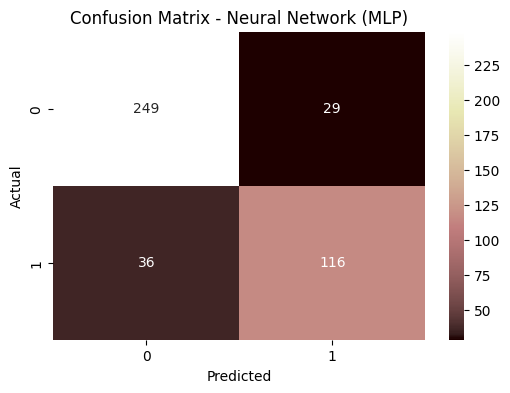

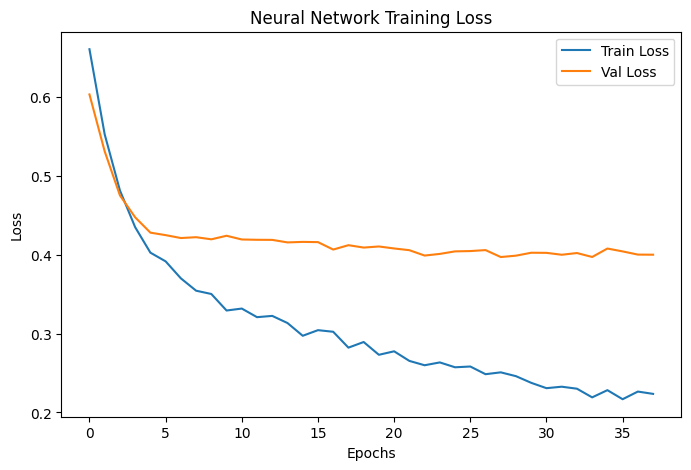

In [17]:
# -----------------------------------------
# SECTION 9: Neural Network (MLP)
# -----------------------------------------

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Build the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')       # Binary classification output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_prob_nn = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

# -----------------------------------------
# METRICS
# -----------------------------------------

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
roc_auc_nn = roc_auc_score(y_test, y_prob_nn)

print("Neural Network Performance Metrics")
print("-----------------------------------------")
print("Accuracy      :", accuracy_nn)
print("Precision     :", precision_nn)
print("Recall        :", recall_nn)
print("F1-score      :", f1_nn)
print("ROC-AUC       :", roc_auc_nn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

# -----------------------------------------
# CONFUSION MATRIX
# -----------------------------------------

cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='pink')
plt.title("Confusion Matrix - Neural Network (MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------------------
# TRAINING HISTORY PLOT
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Neural Network Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Permutation Importance Ranking:


,Feature,ImportanceMean,ImportanceSTD
23,FunctionalAssessment,1.734884e-01,0.013408
26,ADL,1.481395e-01,0.017528
22,MMSE,1.365116e-01,0.016836
24,MemoryComplaints,9.186047e-02,0.010970
25,BehavioralProblems,8.023256e-02,0.009659
20,CholesterolHDL,2.325581e-03,0.001801
4,BMI,1.162791e-03,0.001560
21,CholesterolTriglycerides,2.220446e-17,0.001471
27,Confusion,0.000000e+00,0.000000
5,Smoking,0.000000e+00,0.000000


/tmp/ipython-input-2914397488.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


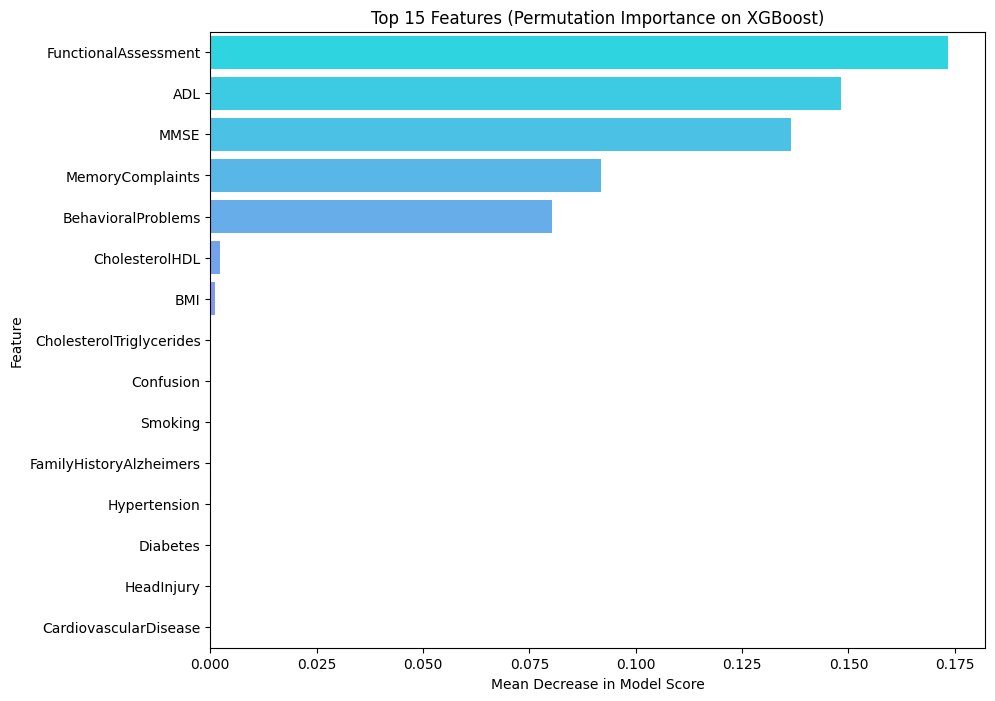

In [18]:
# -----------------------------------------
# SECTION 10: Permutation Importance (XGBoost)
# -----------------------------------------

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To compute permutation importance
result = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# To store results in a DataFrame
perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'ImportanceMean': result.importances_mean,
    'ImportanceSTD': result.importances_std
}).sort_values('ImportanceMean', ascending=False)

# Display full table
print("Permutation Importance Ranking:")
display(perm_importance)

# Plot top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='ImportanceMean',
    y='Feature',
    data=perm_importance.head(15),
    palette='cool'
)
plt.title("Top 15 Features (Permutation Importance on XGBoost)")
plt.xlabel("Mean Decrease in Model Score")
plt.ylabel("Feature")
plt.show()

In [19]:
!pip install shap

SHAP values computed!


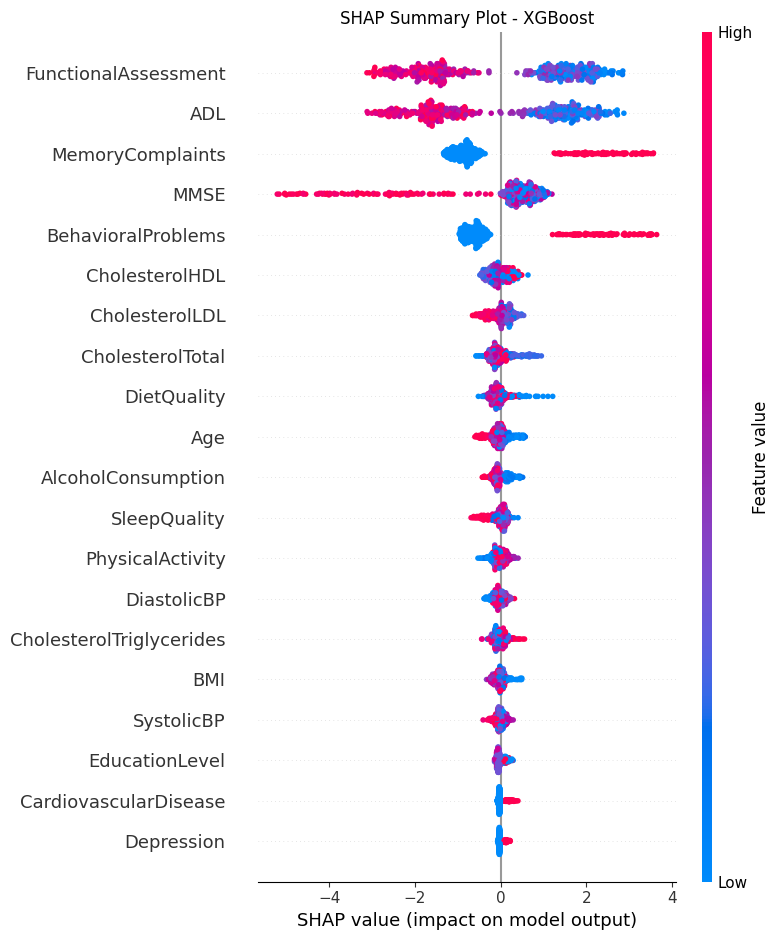

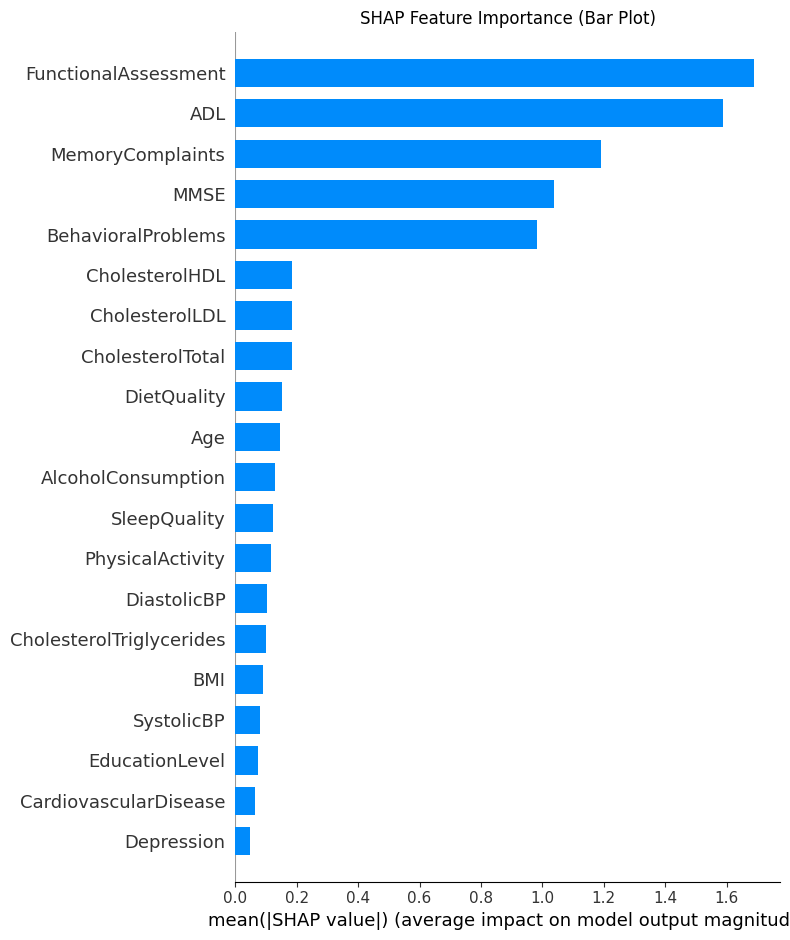


Explaining prediction for ONE PATIENT (index 0):


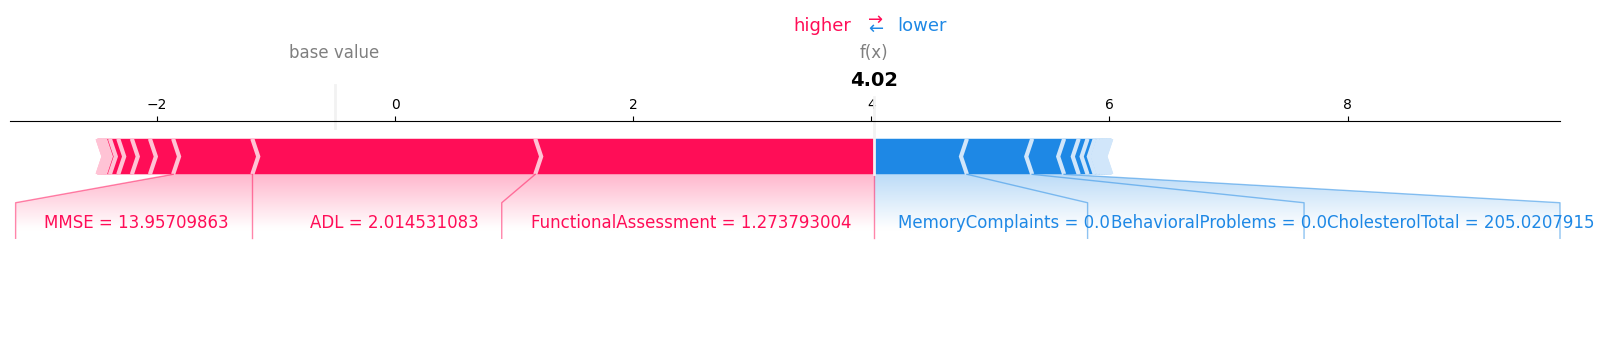

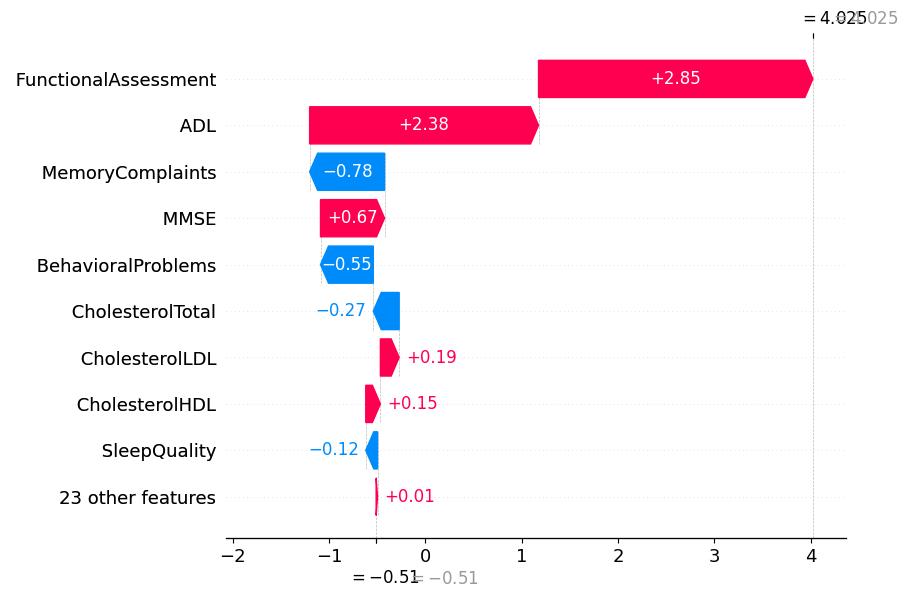

In [20]:
# -----------------------------------------
# SECTION 11: SHAP Explainability for XGBoost
# -----------------------------------------

import shap
import matplotlib.pyplot as plt

# Initialize JavaScript visualization
shap.initjs()

# To create SHAP Explainer for XGBoost
explainer = shap.TreeExplainer(xgb)

# To compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values computed!")

# -----------------------------------------
# GLOBAL FEATURE IMPORTANCE (SUMMARY PLOT)
# -----------------------------------------

plt.title("SHAP Summary Plot - XGBoost")
shap.summary_plot(shap_values, X_test)
plt.show()

# -----------------------------------------
# GLOBAL IMPORTANCE (BAR PLOT)
# -----------------------------------------

plt.title("SHAP Feature Importance (Bar Plot)")
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

# -----------------------------------------
# LOCAL EXPLANATION - ONE PATIENT
# -----------------------------------------

# Choosing an index to explain (example: first patient in test set)
patient_index = 0

print("\nExplaining prediction for ONE PATIENT (index 0):")
shap.force_plot(
    explainer.expected_value,
    shap_values[patient_index, :],
    X_test.iloc[patient_index, :],
    matplotlib=True
)

# -----------------------------------------
# WATERFALL PLOT (Patient-level explanation)
# -----------------------------------------

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[patient_index, :],
    X_test.iloc[patient_index, :]
)

In [21]:
# -----------------------------------------
# SECTION 12A: Model Performance Summary
# -----------------------------------------

import pandas as pd

model_metrics = {
    "Logistic Regression": {
        "Accuracy": accuracy_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F1-score": f1_lr,
        "ROC-AUC": roc_auc_lr
    },
    "Gaussian NB": {
        "Accuracy": accuracy_gnb,
        "Precision": precision_gnb,
        "Recall": recall_gnb,
        "F1-score": f1_gnb,
        "ROC-AUC": roc_auc_gnb
    },
    "Decision Tree": {
        "Accuracy": accuracy_dt,
        "Precision": precision_dt,
        "Recall": recall_dt,
        "F1-score": f1_dt,
        "ROC-AUC": roc_auc_dt
    },
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1-score": f1_rf,
        "ROC-AUC": roc_auc_rf
    },
    "XGBoost": {
        "Accuracy": accuracy_xgb,
        "Precision": precision_xgb,
        "Recall": recall_xgb,
        "F1-score": f1_xgb,
        "ROC-AUC": roc_auc_xgb
    },
    "SVM (RBF)": {
        "Accuracy": accuracy_svm,
        "Precision": precision_svm,
        "Recall": recall_svm,
        "F1-score": f1_svm,
        "ROC-AUC": roc_auc_svm
    },
    "Neural Network": {
        "Accuracy": accuracy_nn,
        "Precision": precision_nn,
        "Recall": recall_nn,
        "F1-score": f1_nn,
        "ROC-AUC": roc_auc_nn
    }
}

metrics_df = pd.DataFrame(model_metrics).T.sort_values("ROC-AUC", ascending=False)
print("Model Performance Summary (sorted by ROC-AUC):")
display(metrics_df)

Model Performance Summary (sorted by ROC-AUC):


,Accuracy,Precision,Recall,F1-score,ROC-AUC
XGBoost,0.948837,0.939189,0.914474,0.926667,0.943440
Random Forest,0.948837,0.945205,0.907895,0.926174,0.939985
Neural Network,0.848837,0.800000,0.763158,0.781145,0.898902
SVM (RBF),0.834884,0.791367,0.723684,0.756014,0.896287
Decision Tree,0.900000,0.847134,0.875000,0.860841,0.894335
Logistic Regression,0.816279,0.741722,0.736842,0.739274,0.885365
Gaussian NB,0.772093,0.670886,0.697368,0.683871,0.850388


In [22]:
# -----------------------------------------
# SECTION 12B: Final Feature Ranking (Permutation + SHAP)
# -----------------------------------------

import numpy as np

# 1. SHAP global importance: mean(|SHAP value|) per feature
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "MeanAbsSHAP": np.mean(np.abs(shap_values), axis=0)
})

# 2. Renaming columns from permutation importance to align
perm_importance_renamed = perm_importance.rename(
    columns={"ImportanceMean": "PermImportanceMean"}
)[["Feature", "PermImportanceMean"]]

# 3. To merge both rankings
final_importance = shap_importance.merge(perm_importance_renamed, on="Feature")

# 4. Sort by SHAP importance (For Combined Score)
final_importance = final_importance.sort_values("MeanAbsSHAP", ascending=False)

print("Combined SHAP + Permutation Importance Ranking:")
display(final_importance)

# 5. To show only top 15 features
print("\nTop 15 Most Important Features (Global):")
display(final_importance.head(15))

Combined SHAP + Permutation Importance Ranking:


,Feature,MeanAbsSHAP,PermImportanceMean
23,FunctionalAssessment,1.689530,1.734884e-01
26,ADL,1.587493,1.481395e-01
24,MemoryComplaints,1.190725,9.186047e-02
22,MMSE,1.039221,1.365116e-01
25,BehavioralProblems,0.981343,8.023256e-02
20,CholesterolHDL,0.184829,2.325581e-03
19,CholesterolLDL,0.183920,-3.488372e-03
18,CholesterolTotal,0.182936,-6.976744e-04
8,DietQuality,0.151150,-2.325581e-04
0,Age,0.145425,-2.325581e-04



Top 15 Most Important Features (Global):


,Feature,MeanAbsSHAP,PermImportanceMean
23,FunctionalAssessment,1.689530,1.734884e-01
26,ADL,1.587493,1.481395e-01
24,MemoryComplaints,1.190725,9.186047e-02
22,MMSE,1.039221,1.365116e-01
25,BehavioralProblems,0.981343,8.023256e-02
20,CholesterolHDL,0.184829,2.325581e-03
19,CholesterolLDL,0.183920,-3.488372e-03
18,CholesterolTotal,0.182936,-6.976744e-04
8,DietQuality,0.151150,-2.325581e-04
0,Age,0.145425,-2.325581e-04


In [3]:
# ============================================
# Model Performance Summary
# ============================================
# Multiple supervised learning algorithms were trained and evaluated on the
# clinical dataset: Logistic Regression, Gaussian Naive Bayes, Decision Tree,
# Random Forest, Support Vector Machine (SVM), XGBoost, and a neural network (MLP).
#
# Model evaluation was performed on a held-out test set using the following metrics:
# accuracy, precision, recall, F1-score, and ROC-AUC.
#
# Tree-based ensemble models—especially XGBoost (and Random Forest)—achieved the
# best overall discriminative performance, showing the highest ROC-AUC and strong
# recall (sensitivity) for Alzheimer’s diagnosis.
#
# Simpler models (Logistic Regression, Gaussian Naive Bayes) produced reasonable
# baselines but were consistently outperformed by the ensemble methods.
#
# SVM and the neural network provided competitive results but did not surpass
# the tree-based ensembles when considering both ROC-AUC and recall together.
#
# ============================================
# Key Predictive Features
# ============================================
# Feature importance was examined using:
#   - Random Forest feature importances
#   - Permutation importance on the XGBoost model
#   - SHAP (SHapley Additive Explanations) values
#
# All three methods consistently identified the same set of dominant variables.
#
# The most influential predictors of Alzheimer’s diagnosis in this dataset were:
#   - FunctionalAssessment
#   - ADL (Activities of Daily Living)
#   - MMSE (Mini-Mental State Examination score)
#   - MemoryComplaints
#
# These variables showed the highest permutation importance scores and mean
# absolute SHAP values, indicating they contribute most to the model's decisions.
#
# This aligns with clinical expectations: functional decline, reduced ability
# to perform daily activities, and impaired cognitive testing are core markers
# of dementia and are strong diagnostic indicators in practice.
#
# ============================================
# Conclusion
# ============================================
# Overall, the results indicate that machine learning models—especially XGBoost
# and Random Forest—can achieve strong diagnostic accuracy for Alzheimer’s disease
# using this clinical dataset.
#
# The models rely predominantly on well-established clinical markers of dementia,
# such as functional impairment, activities of daily living, and cognitive testing.
# Lifestyle and metabolic variables play a secondary role and contribute only
# incremental predictive value.
#
# This suggests that, within this cohort, accurate diagnosis is driven mainly by
# core cognitive and functional measures, while additional variables provide only
# marginal improvements beyond these foundational indicators.
# ============================================